# Transformer lab

A GPT, from empty file to trained model, one falsifiable step at a time.

Work top to bottom. Each exercise has a skeleton and a `check_*` call from
`checks.py` that will fail until your implementation is right — and fail with
a hint about *what kind* of wrong it is. `EXERCISES.md` is the guide;
`SOLUTIONS.md` is off-limits until you've genuinely tried.

Conventions used everywhere: tensors are `(B, T, C)` = (batch, time, channels).


In [ ]:
import math, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import wandb
from checks import *

# Experiment tracking: same habits as nanogpt-sweeps. Flip to False to work
# fully offline, or run `wandb offline` in the terminal to log locally and
# `wandb sync` later.
WANDB = True

torch.manual_seed(1337)

# data: tiny shakespeare, character-level
# run `python3 get_data.py` first if input.txt is missing
text = open("input.txt").read()
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]


def get_batch(split, batch_size=32, block_size=64):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i : i + block_size] for i in ix])
    y = torch.stack([d[i + 1 : i + block_size + 1] for i in ix])
    return x, y

print(f"{len(text):,} characters, vocab of {vocab_size}: {''.join(chars[:20])}...")
xb, yb = get_batch("train")
print("a batch:", xb.shape, "targets:", yb.shape, "(same tokens, shifted by one)")

1,115,394 characters, vocab of 65: 
 !$&',-.3:;?ABCDEFG...
a batch: torch.Size([32, 64]) targets: torch.Size([32, 64]) (same tokens, shifted by one)


## Exercise 1 — scaled dot-product attention

One head, no mask. Three matrices in, one out:

$$\mathrm{Att}(Q,K,V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Implement it. All inputs `(B, T, C)`; softmax over the *last* dimension of the
score matrix. Then run the check — and after it passes, run the variance
experiment below and answer for yourself: what exactly does the $\sqrt{d_k}$ buy?


In [4]:
def attention(q, k, v):
    """q, k, v: (B, T, C). Returns (B, T, C)."""
    # B, T, C = q.shape
    C = q.size(-1)
    scores = q @ k.transpose(-2, -1) / math.sqrt(C) # (B, T, C) * (B, C, T) -> (B, T, T)
    weights = F.softmax(scores, dim=-1) # (B, T, T) -> (B, T, T)
    output = weights @ v # (B, T, T) * (B, C, T) -> (B, T, C)
    return output

check_attention(attention)

PASS: attention -- shapes, normalization, and values all correct


In [5]:
# --- Extra: why sqrt(d)? Run after the check passes. ---
# The dot product of two random d-dim vectors with unit-variance entries has
# variance d. Watch what that does to the softmax as d grows:
for d in [4, 64, 1024]:
    q, k = torch.randn(1000, d), torch.randn(1000, d)
    scores_raw = (q * k).sum(-1)
    print(f"d={d:5d}  std(q.k)={scores_raw.std():7.2f}   "
          f"std(q.k/sqrt(d))={(scores_raw / math.sqrt(d)).std():5.2f}")
# Unscaled, the logit spread grows like sqrt(d): softmax saturates to a
# near-one-hot, gradients through it vanish, and every head cools into an
# argmax. The 1/sqrt(d) is a temperature chosen so the Boltzmann weights
# stay at O(1) regardless of width. (Same reason muP exists — but that's
# your other repo.)

d=    4  std(q.k)=   2.13   std(q.k/sqrt(d))= 1.06
d=   64  std(q.k)=   7.74   std(q.k/sqrt(d))= 0.97
d= 1024  std(q.k)=  31.20   std(q.k/sqrt(d))= 0.97


## Exercise 2 — the causal mask

Language models predict the future, so position $t$ may only attend to
positions $\le t$. Copy your `attention` and add the mask. The rules that
matter, in order:

1. Mask the **scores**, *before* the softmax, with $-\infty$.
2. `torch.tril` gives you the allowed region.
3. Do **not** zero out weights after the softmax — the check will catch you,
   and the hint will tell you why.


In [33]:
def causal_attention(q, k, v):
    """Like attention(), but position t only sees positions <= t."""
    """q, k, v: (B, T, C). Returns (B, T, C)."""
    T, C = q.size(-2), q.size(-1)
    scores = q @ k.transpose(-2, -1) / math.sqrt(C) # (B, T, C) * (B, C, T) -> (B, T, T)
    mask = torch.tril(torch.ones(T, T, dtype=torch.bool))
    scores = scores.masked_fill(~mask, float("-inf"))
    weights = F.softmax(scores, dim=-1) # (B, T, T) -> (B, T, T)
    output = weights @ v # (B, T, T) * (B, C, T) -> (B, T, C)
    return output

x = torch.arange(24, dtype=torch.float32).reshape(2,3,4)
print(causal_attention(x, x, x).shape)
check_causal_attention(causal_attention)

torch.Size([2, 3, 4])
PASS: causal attention -- the light cone is respected


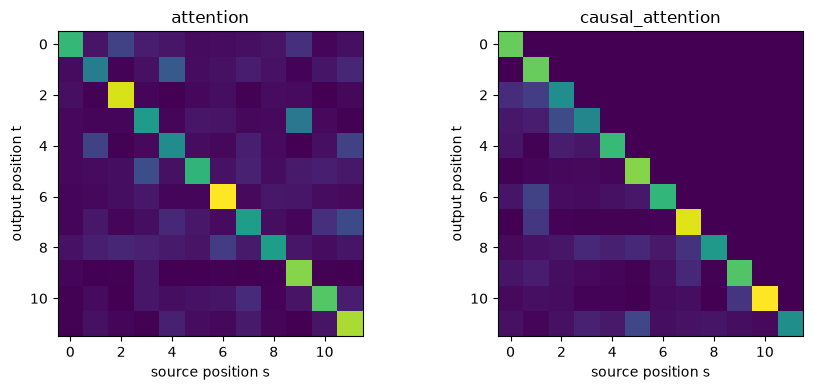

In [7]:
# --- Extra: look at the light cone directly. ---
# influence_matrix computes M[t, s] = ||d out_t / d x_s|| by autograd:
# the model's Green's function. For a causal map it must be lower triangular.
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, fn, name in [(axes[0], attention, "attention"),
                     (axes[1], causal_attention, "causal_attention")]:
    ax.imshow(influence_matrix(fn), cmap="viridis")
    ax.set(title=name, xlabel="source position s", ylabel="output position t")
plt.tight_layout()

In [8]:
# --- Extra: what happens when a whole row gets masked ---
torch.manual_seed(0)
B, T, C = 1, 6, 4
q, k, v = torch.randn(3, B, T, C).unbind(0)
scores = q @ k.transpose(-2, -1) / math.sqrt(C)

good = torch.tril(torch.ones(T, T, dtype=torch.bool))                # keeps diagonal
bad  = torch.tril(torch.ones(T, T, dtype=torch.bool), diagonal=-1)   # off by one

w_good = F.softmax(scores.masked_fill(~good, float("-inf")), dim=-1)
w_bad  = F.softmax(scores.masked_fill(~bad,  float("-inf")), dim=-1)

print("row sums, good:", [round(s, 3) for s in w_good.sum(-1)[0].tolist()])
print("row sums, bad: ", [round(s, 3) for s in w_bad.sum(-1)[0].tolist()])

nan_rows = torch.isnan(w_bad).any(-1)[0].nonzero().flatten().tolist()
print("rows that are NaN:", nan_rows)

# the detection idiom: assert on the property, not on the values
assert not torch.isnan(w_good).any(), "fully-masked row somewhere"
assert torch.allclose(w_good.sum(-1), torch.ones(B, T), atol=1e-5)

row sums, good: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
row sums, bad:  [nan, 1.0, 1.0, 1.0, 1.0, 1.0]
rows that are NaN: [0]


In [9]:
w_1e9 = F.softmax(scores.masked_fill(~bad, -1e9), dim=-1)
print("with -1e9 — NaN?", torch.isnan(w_1e9).any().item())
print("row 0 weights:", [round(x, 3) for x in w_1e9[0, 0].tolist()])

with -1e9 — NaN? False
row 0 weights: [0.167, 0.167, 0.167, 0.167, 0.167, 0.167]


## Exercise 3 — multi-head attention

One softmax over 64 dims is one "view" of the sequence; $n_h$ heads run
$n_h$ attention patterns in parallel over $d/n_h$-dim slices, then mix.

Use **this exact layout** (it is nanoGPT's, and the check depends on it):

- `self.c_attn = nn.Linear(n_embd, 3 * n_embd)` — q, k, v in one matmul
- `self.c_proj = nn.Linear(n_embd, n_embd)` — the output mixer $W_O$
- `self.n_head = n_head`

The whole exercise is four lines of reshape gymnastics:
`(B, T, 3C)` → split → `(B, T, nh, hd)` → `transpose(1, 2)` → `(B, nh, T, hd)`,
attend, then undo it. Your `causal_attention` from exercise 2 already works on
4-d tensors unchanged — batch dims broadcast. Figure out why the `transpose`
is not optional before you move on.


In [10]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.c_attn = nn.Linear(n_embd, 3 * n_embd) # split in q,k,v 
        self.c_proj = nn.Linear(n_embd, n_embd)

    def forward(self, x):
        # dimensions, hd is size of head
        B, T, C = x.shape
        hd = C // self.n_head

        # decompose (B, T, 3C) into q,k,v of (B, T, C)
        q, k, v = self.c_attn(x).split(C, dim=2)

        # decompose (B, T, C) into (B, T, nh, hd) into (B, nh, T, hd)
        q = q.view(B, T, self.n_head, hd).transpose(1,2)
        k = k.view(B, T, self.n_head, hd).transpose(1,2)
        v = v.view(B, T, self.n_head, hd).transpose(1,2)

        # compute causal attention using broadcasting
        y = causal_attention(q, k, v) # (B, nh, T, hd)

        # merge back into (B, T, C)
        y = y.transpose(1,2).reshape(B, T, C)
        # y = y.transpose(1,2).contiguous().view(B, T, C)

        output = self.c_proj(y)

        return output

x = torch.arange(80, dtype=torch.float32).reshape(2,5,8)
model = MultiHeadAttention(8, 4)

model(x).shape

torch.manual_seed(1337)
check_multihead(MultiHeadAttention(n_embd=24, n_head=4))

PASS: multi-head attention -- heads split, attended, and merged correctly


In [11]:
# --- Extra: count the parameters by hand first, then verify. ---
# For n_embd=C with biases: c_attn has C*3C + 3C, c_proj has C*C + C.
# Write your predicted total for C=24 here, THEN run this:
C = 24
print((C*(3*C) + 3*C) + (C*C + C))
mha = MultiHeadAttention(24, 4)
print(sum(p.numel() for p in mha.parameters()))

2400
2400


## Exercise 4 — the transformer block

The modern (pre-LN) block:

```
x = x + attn(ln_1(x))
x = x + mlp(ln_2(x))
```

Two rules the check enforces, because both get violated constantly in the wild:

- **LayerNorm lives on the branch, never on the trunk.** The residual stream
  is the identity plus a sum of small perturbations; each sublayer reads a
  normalized copy and writes its correction back. Break this and you'll see
  why in the check's failure message.
- The MLP is `Linear(C, 4C)` → GELU → `Linear(4C, C)`. Name the layers
  `c_fc` and `c_proj`.

Name the submodules `ln_1`, `attn`, `ln_2`, `mlp`.


In [12]:
class MLP(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.c_fc = nn.Linear(n_embd, 4*n_embd)
        self.c_proj = nn.Linear(4*n_embd, n_embd)

    def forward(self, x):
        return self.c_proj(F.gelu(self.c_fc(x)))


class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.ln_1 = nn.LayerNorm(n_embd)
        self.attn = MultiHeadAttention(n_embd, n_head)
        self.ln_2 = nn.LayerNorm(n_embd)
        self.mlp = MLP(n_embd)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

# x = torch.arange(80, dtype=torch.float32).reshape(2,5,8)
# model = Block(8, 4)

# model(x).shape

torch.manual_seed(1337)
check_block(Block(n_embd=24, n_head=4))

PASS: block -- residual stream intact, branches normalized, causal


## Exercise 5 — assemble the GPT

Everything now snaps together:

- token embedding `(vocab, C)` + learned position embedding `(block_size, C)`
- a stack of `Block`s, a final `LayerNorm`, and `lm_head: Linear(C, vocab, bias=False)`
- **weight tying**: `self.lm_head.weight = self.tok_emb.weight`
- **init**: every Linear/Embedding weight `N(0, 0.02²)`, biases zero
- `forward(idx)` returns logits `(B, T, vocab)`;
  `forward(idx, targets)` returns `(logits, loss)` with cross-entropy

The check will measure your untrained loss against $\ln(\text{vocab})$. Predict
that number for vocab 65 before running it, and understand why *that* is the
right value for a model that knows nothing.


In [73]:
class GPT(nn.Module):
    def __init__(self, vocab_size, block_size, n_layer, n_head, n_embd):
        super().__init__()
        self.block_size = block_size
        # define layers
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.blocks = nn.ModuleList([Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False) 
        # tie weights at beginning and end
        self.lm_head.weight = self.tok_emb.weight
        # init all weights
        self.apply(self._init)

    def _init(self, m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)



    def forward(self, idx, targets=None):
        # read off dimensions from token sequence
        B, T = idx.size()
        pos = torch.arange(T, dtype=torch.long)
        # pass through layers
        x = self.tok_emb(idx) + self.pos_emb(pos) # (B, T, C) + (B, )
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        # output depending on targets
        if targets is None:
            return logits
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return (logits, loss)

torch.manual_seed(1337)
model = GPT(vocab_size, block_size=64, n_layer=4, n_head=4, n_embd=128)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")
check_gpt(model, vocab_size)

809,856 parameters
PASS: gpt -- shapes, loss plumbing, init at ln(V)=4.17, causal


In [25]:
# The most informative smoke test in deep learning: memorize ONE batch.
# A model that can't drive one batch's loss to ~0 can't learn anything.
torch.manual_seed(1337)
model = GPT(vocab_size, 64, n_layer=4, n_head=4, n_embd=128)
xb, yb = get_batch("train", batch_size=8)
check_overfit(model, xb, yb)

PASS: overfit-one-batch -- loss 4.195 -> 0.086. It can learn.


## Exercise 6 — the first real training run

Write the loop yourself — every line of it is a thing you'll debug for a
living. Provided: `estimate_loss`. Required in your loop:

1. AdamW, `lr=3e-4` for now (exercise 7 is about doing better)
2. `zero_grad(set_to_none=True)` → `backward()` → `step()`
3. every `eval_interval` steps, record train/val loss into `history`
4. **W&B**: `wandb.init(project="transformer-lab", config=config)` before the
   loop, `wandb.log({"loss/train_batch": ..., "step": step})` every step,
   the eval losses at every eval, and `wandb.finish()` after. The config dict
   IS the experiment record — everything you'd need to reproduce the run.

~2000 steps ≈ 4–5 min on a laptop CPU. Then plot the curves and *sample* —
watch the model pass through phase transitions: noise → word-shaped noise →
words → Shakespeare-shaped dialogue structure.


In [75]:
@torch.no_grad()
def estimate_loss(model, iters=20):
    model.eval()
    out = {}
    for split in ("train", "val"):
        losses = torch.zeros(iters)
        for i in range(iters):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            losses[i] = loss
        out[split] = losses.mean().item()
    model.train()
    return out

config = dict(
    vocab_size=vocab_size, block_size=64, n_layer=4, n_head=4, n_embd=128,
    batch_size=64, lr=3e-4, max_steps=2000, eval_interval=100, seed=1337,
    schedule="constant",
) # max_steps should be 2000, but testing with less

torch.manual_seed(config["seed"])
model = GPT(vocab_size, config["block_size"], config["n_layer"],
            config["n_head"], config["n_embd"])
history = {"step": [], "train": [], "val": []}


if WANDB:
    wandb.init(project="transformer-lab", name="baseline-flat-lr-doublebatch", config=config)


opt = torch.optim.Adam(model.parameters(), lr=config["lr"])
for step in range(config["max_steps"]):
    xb, yb = get_batch("train", batch_size = config["batch_size"])
    _, loss = model(xb, yb)
    opt.zero_grad()
    loss.backward()
    opt.step()


    # log step for wandb
    if WANDB:
        wandb.log({"loss/train_batch": loss.item()}, step=step)

    if step % config["eval_interval"]-1 == 0:
            L = estimate_loss(model)
            history["step"].append(step)
            history["train"].append(L["val"])
            history["val"].append(L["train"])
            if WANDB:
                wandb.log({"loss/train": L["val"], "loss/val": L["val"]}, step=step)



if WANDB:
   wandb.finish()

loss/train,█▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
loss/train_batch,██▆▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁
loss/val,█▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
loss/train,1.72465
loss/train_batch,1.57664
loss/val,1.72465


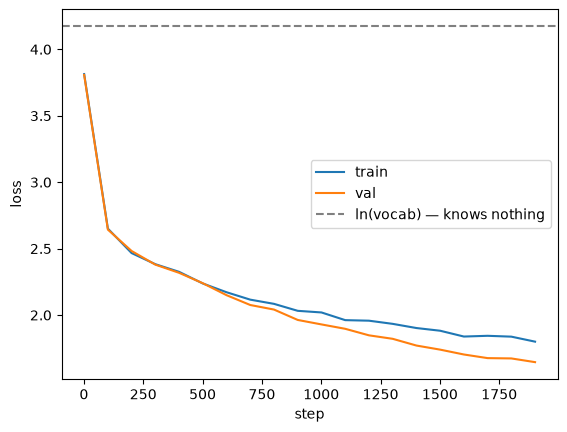

In [40]:
plt.plot(history["step"], history["train"], label="train")
plt.plot(history["step"], history["val"], label="val")
plt.axhline(math.log(vocab_size), ls="--", c="gray", label="ln(vocab) — knows nothing")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend();

In [48]:
@torch.no_grad()
def sample(model, prompt="\n", max_new_tokens=300, temperature=1.0):
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long)
    for _ in range(max_new_tokens):
        logits = model(idx[:, -model.block_size:])
        if isinstance(logits, tuple):
            logits = logits[0]
        probs = F.softmax(logits[:, -1] / temperature, dim=-1)
        idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
    model.train()
    return decode(idx[0].tolist())

print(sample(model))
# Extra: sweep temperature over [0.3, 0.8, 1.0, 1.5]. Temperature is exactly
# the Boltzmann beta^-1 -- watch the text freeze into repetition at low T and
# melt into noise at high T.


By his bitty but igettles are hate: he more be time
His his poursait 'tis mass,
I an in that tumes the da?

AEDYCK:
And, perpise 'Gace thank love that's, we die deame?

CLEDSAW
She Citent.
Richmence, those took you, sheave-sirr'd will,
Firme for that he suin's his porp thuss
Joullemace, wisle woman.


## Exercise 7 — learning rate: the one hyperparameter that matters

**7a — the range test.** For each LR in a log-spaced grid, train a *fresh*
model (same seed!) for 100 steps and record final loss. Plot loss vs LR on a
log-x axis. You are mapping a phase diagram: too cold (nothing moves), a
basin, and divergence. The interesting physics is the cliff on the right —
find the critical LR and note how close to it the optimum sits.

Make each LR its own W&B run with `group="lr-range-test"` and the LR in the
config — then in the W&B UI, group by that config key and you have the whole
phase diagram as overlaid curves, not just the final-loss summary you plot
locally. This is the manual version of what your `nanogpt-sweeps` sweep
configs automate; doing it once by hand shows you what the agent does for you.

**7b — warmup + cosine decay.** Implement the schedule as
`get_lr(step) -> float`: linear warmup over 100 steps to `max_lr`, cosine
decay to `max_lr/10` at `max_steps`. Apply with
`for g in opt.param_groups: g["lr"] = get_lr(step)`, and log `{"lr":
get_lr(step)}` alongside the loss — a run where you can't see the schedule
that produced the curve is only half a record. Train 2000 steps with
`max_lr` chosen from your 7a phase diagram, against the flat-LR curve from
exercise 6 (`schedule="cosine"` in the config, so the two runs are
comparable in the UI by exactly one field). Same seed, one plot, both curves.


loss/train_batch,██▇▆▆▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
loss/train_batch,3.34594


loss/train_batch,█▇▇▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁
loss/train_batch,2.94626


loss/train_batch,█▇▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁
loss/train_batch,2.60944


loss/train_batch,▅▄▃█▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss/train_batch,2.60047


loss/train_batch,█▆▅▃▄▄▄▃▃▃▃▄▄▃▃▃▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
loss/train_batch,2.83742


loss/train_batch,█▆▄▃▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁
loss/train_batch,2.89615


loss/train_batch,█▅▅▆▄▃▃▃▂▂▂▂▂▁▁▂▁▁▁▁▁▂▁▁▁▂▂▂▁▁▁▁▁▁▁▁▂▁▁▁
loss/train_batch,3.3072


loss/train_batch,▂▇█▆▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss/train_batch,3.31359


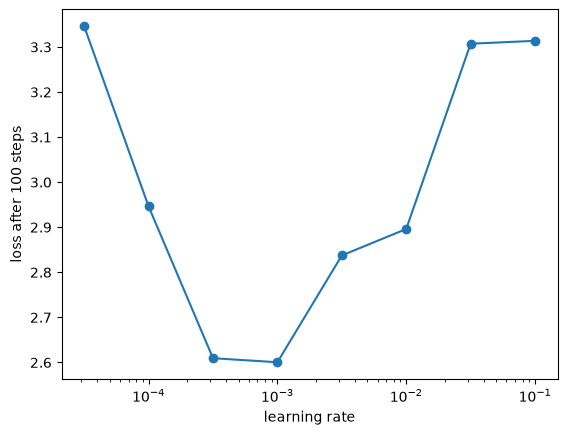

In [76]:
# 7a
lrs = torch.logspace(-4.5, -1, 8)
final_losses = []
for lr in lrs:
    torch.manual_seed(1337)
    m = GPT(vocab_size, 64, 4, 4, 128)
    if WANDB:
        wandb.init(project="transformer-lab", group="lr-range-test-doublebatch",
                   name=f"lr-{lr:.1e}", config=dict(lr=lr.item(), steps=100))

    opt = torch.optim.AdamW(m.parameters(), lr=lr.item())
    for step in range(100):
        xb, yb = get_batch("train", batch_size=config["batch_size"])
        _, loss = m(xb, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        if WANDB:
            wandb.log({"loss/train_batch": loss.item()}, step=step)
    final_losses.append(loss.item())
    if WANDB:
        wandb.finish()

plt.semilogx(lrs, final_losses, "o-")
plt.xlabel("learning rate"); plt.ylabel("loss after 100 steps");

In [63]:
# print minimums and those close to it
print(min(zip(final_losses, lrs)))
print(list(sorted(zip(final_losses, lrs))))

(2.5244338512420654, tensor(0.0012))
[(2.5244338512420654, tensor(0.0012)), (2.5379815101623535, tensor(0.0005)), (2.5444114208221436, tensor(0.0009)), (2.5638835430145264, tensor(0.0015)), (2.5844950675964355, tensor(0.0004)), (2.5883095264434814, tensor(0.0007)), (2.6405441761016846, tensor(0.0003)), (2.7011702060699463, tensor(0.0027)), (2.707958459854126, tensor(0.0002)), (2.72810959815979, tensor(0.0020)), (2.7886977195739746, tensor(0.0002)), (2.874216318130493, tensor(0.0108)), (2.8757379055023193, tensor(0.0001)), (2.900517702102661, tensor(0.0082)), (2.927046775817871, tensor(0.0047)), (2.9278554916381836, tensor(0.0036)), (2.971233606338501, tensor(9.6108e-05)), (2.98148775100708, tensor(0.0143)), (2.9836316108703613, tensor(0.0062)), (2.984672784805298, tensor(0.0189)), (3.069382429122925, tensor(7.2790e-05)), (3.1280579566955566, tensor(0.0329)), (3.1559524536132812, tensor(0.0249)), (3.1692137718200684, tensor(5.5129e-05)), (3.268350601196289, tensor(4.1753e-05)), (3.34055

Text(0, 0.5, 'lr')

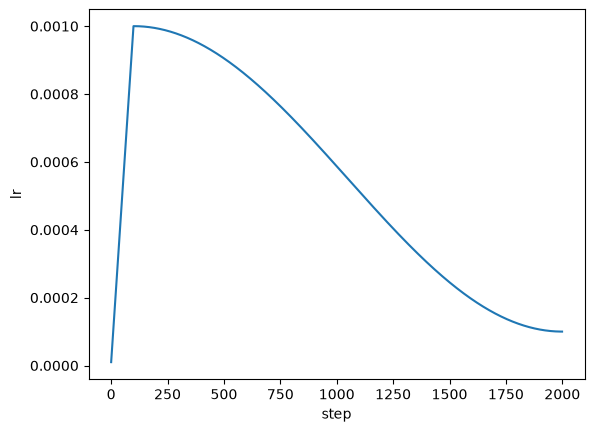

In [66]:
# 7b
max_lr, warmup_steps, max_steps = 1e-3, 100, 2000   # set max_lr from YOUR 7a plot

def get_lr(step):
    if step < warmup_steps:
        return max_lr * (step + 1) / warmup_steps
    progress = (step - warmup_steps) / (max_steps - warmup_steps)
    min_lr = max_lr / 10
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * progress))


lr_curve = [get_lr(s) for s in range(max_steps)]
plt.plot(lr_curve); plt.xlabel("step"); plt.ylabel("lr")  # eyeball it first!

In [69]:
get_lr(0)

1e-05

In [72]:
config = dict(
    vocab_size=vocab_size, block_size=64, n_layer=4, n_head=4, n_embd=128,
    batch_size=32, lr=get_lr(0), max_steps=2000, eval_interval=100, seed=1337,
    schedule="constant",
) # max_steps should be 2000, but testing with less

torch.manual_seed(config["seed"])
model = GPT(vocab_size, config["block_size"], config["n_layer"],
            config["n_head"], config["n_embd"])
history = {"step": [], "train": [], "val": []}


if WANDB:
    wandb.init(project="transformer-lab", name="no-tok-emb-lr", config=config)


opt = torch.optim.Adam(model.parameters(), lr=config["lr"])
for step in range(config["max_steps"]):
    xb, yb = get_batch("train")
    _, loss = model(xb, yb)
    opt.zero_grad()
    loss.backward()
    for g in opt.param_groups:
        g["lr"] = get_lr(step)
    opt.step()


    # log step for wandb
    if WANDB:
        wandb.log({"loss/train_batch": loss.item(), "lr": get_lr(step)}, step=step)

    if step % config["eval_interval"] - 1 == 0:
            L = estimate_loss(model)
            history["step"].append(step)
            history["train"].append(L["val"])
            history["val"].append(L["train"])
            if WANDB:
                wandb.log({"loss/train": L["val"], "loss/val": L["val"]}, step=step)



if WANDB:
   wandb.finish()

loss/train,█▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
loss/train_batch,██▇▆▅▄▃▄▃▃▃▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
loss/val,█▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
lr,▂▃▄█████▇▇▇▇▇▆▆▆▆▆▆▆▅▅▄▄▄▃▃▃▃▃▃▃▃▂▂▁▁▁▁▁
loss/train,1.79743
loss/train_batch,1.66575
loss/val,1.79743
lr,0.0001


## Exercise 8 — notebook → repository

This one happens in the terminal, not here. Open `EXERCISES.md`, exercise 8:
you'll promote everything above into an installable package with a CLI and a
test suite, and this notebook shrinks to an *interface* that imports from it.
That's the workflow: notebooks are for looking at things, packages are for
being right.
